In [ ]:
# Install PyTorch Geometric
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.datasets import Planetoid

# Load Cora — downloads automatically!
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features per node: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")
print(f"Training nodes: {data.train_mask.sum()}")
print(f"Test nodes: {data.test_mask.sum()}")

Processing...


Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Training nodes: 140
Test nodes: 1000


Done!


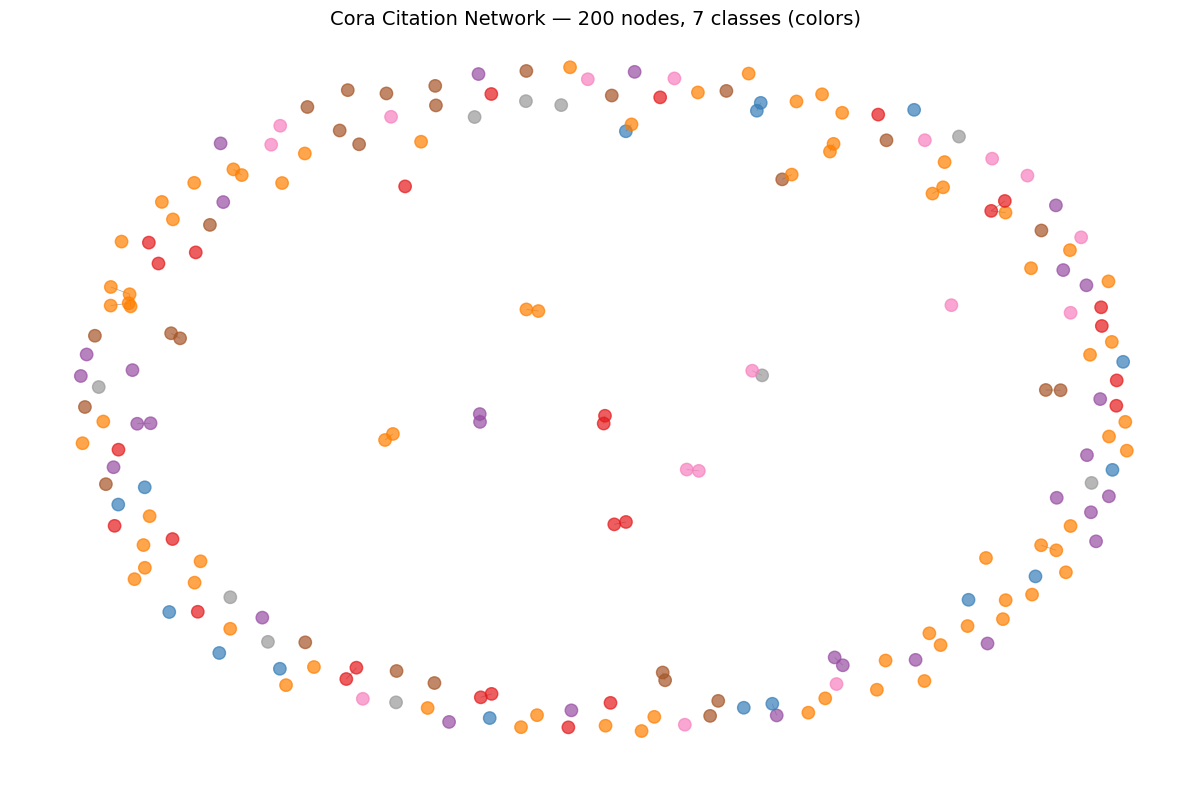

✅ Graph saved as cora_graph.png


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.utils import to_networkx

# Convert to NetworkX graph
G = to_networkx(data, to_undirected=True)

# Pick 200 random nodes to visualize (full graph is too dense)
np.random.seed(42)
sampled_nodes = np.random.choice(data.num_nodes, 200, replace=False)
subgraph = G.subgraph(sampled_nodes)

# Get class labels for colors
labels = data.y.numpy()
node_colors = [labels[n] for n in subgraph.nodes()]

# Plot!
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw_networkx(
    subgraph,
    pos=pos,
    node_color=node_colors,
    cmap=plt.cm.Set1,
    node_size=80,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.5
)
plt.title("Cora Citation Network — 200 nodes, 7 classes (colors)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('cora_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph saved as cora_graph.png")

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# ── Model ──────────────────────────────────────────
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, 64)
        self.conv2 = GCNConv(64, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ── Train ──────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

gcn_model = GCN().to(device)
gcn_data  = data.to(device)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)

gcn_losses     = []
gcn_accuracies = []

for epoch in range(200):
    gcn_model.train()
    optimizer.zero_grad()
    out  = gcn_model(gcn_data)
    loss = F.nll_loss(out[gcn_data.train_mask], gcn_data.y[gcn_data.train_mask])
    loss.backward()
    optimizer.step()

    # Test accuracy
    gcn_model.eval()
    with torch.no_grad():
        pred = gcn_model(gcn_data).argmax(dim=1)
        acc  = (pred[gcn_data.test_mask] == gcn_data.y[gcn_data.test_mask]).float().mean()

    gcn_losses.append(loss.item())
    gcn_accuracies.append(acc.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

print(f"\n✅ Final GCN Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")

Using device: cuda
Epoch  20 | Loss: 0.0191 | Test Acc: 0.7930
Epoch  40 | Loss: 0.0072 | Test Acc: 0.7970
Epoch  60 | Loss: 0.0134 | Test Acc: 0.8090
Epoch  80 | Loss: 0.0133 | Test Acc: 0.8170
Epoch 100 | Loss: 0.0130 | Test Acc: 0.8080
Epoch 120 | Loss: 0.0137 | Test Acc: 0.8030
Epoch 140 | Loss: 0.0101 | Test Acc: 0.8130
Epoch 160 | Loss: 0.0103 | Test Acc: 0.8050
Epoch 180 | Loss: 0.0096 | Test Acc: 0.8090
Epoch 200 | Loss: 0.0090 | Test Acc: 0.8090

✅ Final GCN Test Accuracy: 0.8090 (80.9%)


In [ ]:
from torch_geometric.nn import GATConv

# ── Model ──────────────────────────────────────────
class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # 8 attention heads × 8 features = 64
        self.conv1 = GATConv(dataset.num_node_features, 8, heads=8, dropout=0.6)
        self.conv2 = GATConv(64, dataset.num_classes, heads=1, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ── Train ──────────────────────────────────────────
gat_model = GAT().to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

gat_losses     = []
gat_accuracies = []

for epoch in range(200):
    gat_model.train()
    optimizer.zero_grad()
    out  = gat_model(gcn_data)
    loss = F.nll_loss(out[gcn_data.train_mask], gcn_data.y[gcn_data.train_mask])
    loss.backward()
    optimizer.step()

    gat_model.eval()
    with torch.no_grad():
        pred = gat_model(gcn_data).argmax(dim=1)
        acc  = (pred[gcn_data.test_mask] == gcn_data.y[gcn_data.test_mask]).float().mean()

    gat_losses.append(loss.item())
    gat_accuracies.append(acc.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

print(f"\n✅ Final GAT Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")

Epoch  20 | Loss: 0.9341 | Test Acc: 0.7890
Epoch  40 | Loss: 0.7006 | Test Acc: 0.7900
Epoch  60 | Loss: 0.5894 | Test Acc: 0.8060
Epoch  80 | Loss: 0.5738 | Test Acc: 0.7950
Epoch 100 | Loss: 0.3501 | Test Acc: 0.8070
Epoch 120 | Loss: 0.4136 | Test Acc: 0.8060
Epoch 140 | Loss: 0.3653 | Test Acc: 0.7920
Epoch 160 | Loss: 0.3720 | Test Acc: 0.8030
Epoch 180 | Loss: 0.3939 | Test Acc: 0.7940
Epoch 200 | Loss: 0.3939 | Test Acc: 0.8030

✅ Final GAT Test Accuracy: 0.8030 (80.3%)


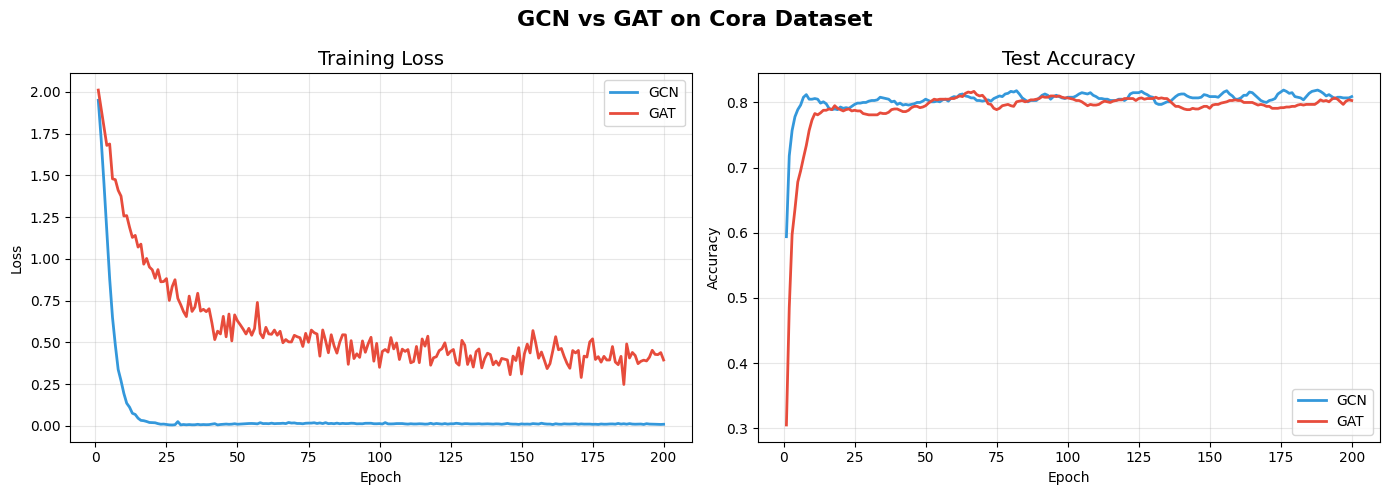

✅ Training curves saved!


In [ ]:
# ── Plot Loss & Accuracy Curves ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 201)

# Loss curves
axes[0].plot(epochs, gcn_losses, color='#3498db', linewidth=2, label='GCN')
axes[0].plot(epochs, gat_losses, color='#e74c3c', linewidth=2, label='GAT')
axes[0].set_title('Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs, gcn_accuracies, color='#3498db', linewidth=2, label='GCN')
axes[1].plot(epochs, gat_accuracies, color='#e74c3c', linewidth=2, label='GAT')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('GCN vs GAT on Cora Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

Running t-SNE... (takes ~30 seconds)
✅ t-SNE done!


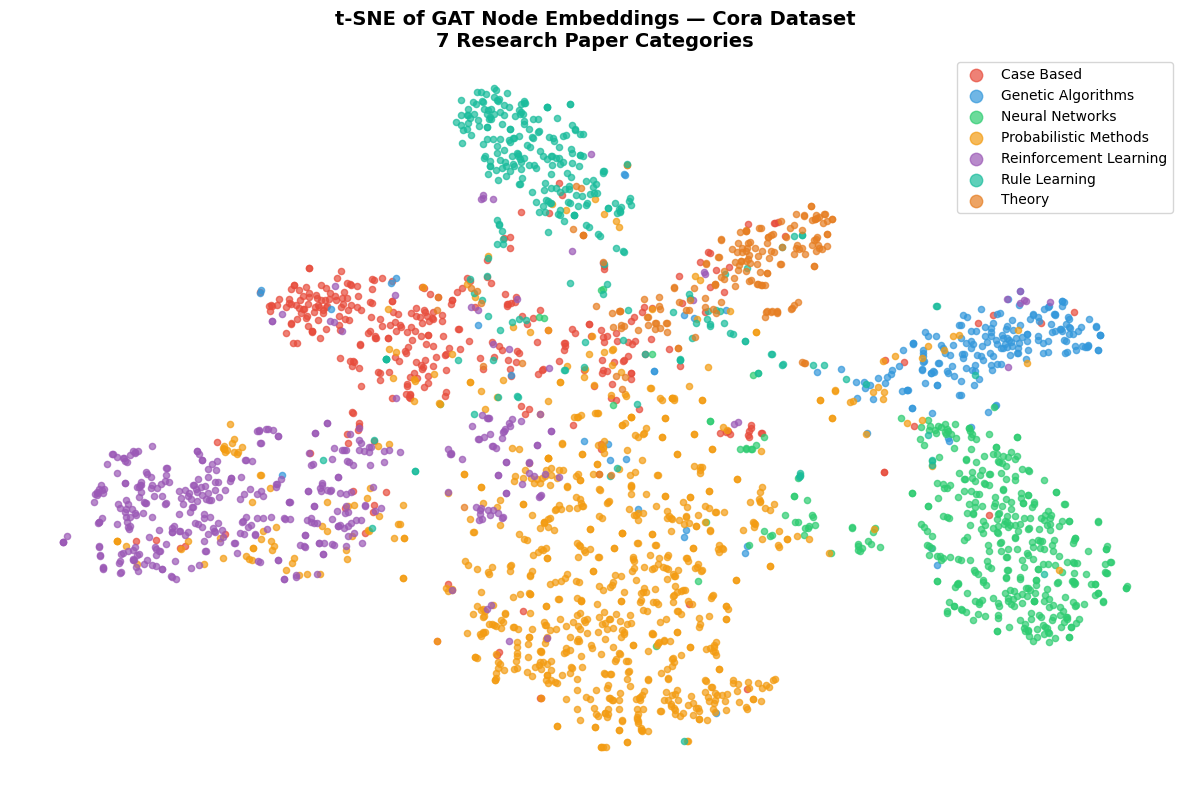

✅ t-SNE plot saved as embeddings_tsne.png!


In [ ]:
from sklearn.manifold import TSNE

# ── Extract embeddings from best model (GAT) ──────────────────
gat_model.eval()
with torch.no_grad():
    x, edge_index = gcn_data.x, gcn_data.edge_index
    x = F.dropout(x, p=0.0, training=False)
    embeddings = gat_model.conv1(x, edge_index)
    embeddings = F.elu(embeddings)
    embeddings = embeddings.cpu().numpy()   # ✅ .cpu() first

labels_np = data.y.cpu().numpy()           # ✅ .cpu() added here

# ── Run t-SNE ─────────────────────────────────────────────────
print("Running t-SNE... (takes ~30 seconds)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)
print("✅ t-SNE done!")

# ── Plot ──────────────────────────────────────────────────────
class_names = [
    'Case Based', 'Genetic Algorithms', 'Neural Networks',
    'Probabilistic Methods', 'Reinforcement Learning',
    'Rule Learning', 'Theory'
]
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

plt.figure(figsize=(12, 8))
for class_id in range(7):
    mask = labels_np == class_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=colors[class_id],
        label=class_names[class_id],
        alpha=0.7,
        s=20
    )

plt.title("t-SNE of GAT Node Embeddings — Cora Dataset\n7 Research Paper Categories",
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, markerscale=2)
plt.axis('off')
plt.tight_layout()
plt.savefig('embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE plot saved as embeddings_tsne.png!")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ── Use raw node features only (no graph structure) ───────────
X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

# Same train/test split as GCN/GAT
train_mask = data.train_mask.cpu().numpy()
test_mask  = data.test_mask.cpu().numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))

print(f"✅ Logistic Regression (no graph): {lr_acc:.4f} ({lr_acc*100:.1f}%)")

# ── Final Comparison Table ─────────────────────────────────────
gcn_final = max(gcn_accuracies)
gat_final = max(gat_accuracies)

print("\n" + "="*45)
print(f"{'Model':<30} {'Test Accuracy':>12}")
print("="*45)
print(f"{'Logistic Regression (no graph)':<30} {lr_acc*100:>11.1f}%")
print(f"{'GCN':<30} {gcn_final*100:>11.1f}%")
print(f"{'GAT':<30} {gat_final*100:>11.1f}%")
print("="*45)
print("\nGraph structure contribution:")
print(f"GCN improvement over baseline: +{(gcn_final-lr_acc)*100:.1f}%")
print(f"GAT improvement over baseline: +{(gat_final-lr_acc)*100:.1f}%")

✅ Logistic Regression (no graph): 0.5760 (57.6%)

Model                          Test Accuracy
Logistic Regression (no graph)        57.6%
GCN                                   81.9%
GAT                                   81.7%

Graph structure contribution:
GCN improvement over baseline: +24.3%
GAT improvement over baseline: +24.1%


In [ ]:
from google.colab import files

files.download('cora_graph.png')
files.download('training_curves.png')
files.download('embeddings_tsne.png')
print("✅ All images downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All images downloaded!
